In [9]:
!pip install pgmpy

  Using cached pgmpy-0.1.26-py3-none-any.whl.metadata (9.1 kB)
  Using cached statsmodels-0.14.4-cp313-cp313-macosx_11_0_arm64.whl.metadata (9.2 kB)
  Using cached google_generativeai-0.8.4-py3-none-any.whl.metadata (4.2 kB)
  Using cached google_ai_generativelanguage-0.6.15-py3-none-any.whl.metadata (5.7 kB)
  Using cached google_auth-2.38.0-py2.py3-none-any.whl.metadata (4.8 kB)
  Using cached pydantic-2.10.6-py3-none-any.whl.metadata (30 kB)
  Using cached patsy-1.0.1-py2.py3-none-any.whl.metadata (3.3 kB)
  Using cached pyasn1_modules-0.4.1-py3-none-any.whl.metadata (3.5 kB)
  Using cached rsa-4.9-py3-none-any.whl.metadata (4.2 kB)
  Using cached httplib2-0.22.0-py3-none-any.whl.metadata (2.6 kB)
  Using cached google_auth_httplib2-0.2.0-py2.py3-none-any.whl.metadata (2.2 kB)
  Using cached uritemplate-4.1.1-py2.py3-none-any.whl.metadata (2.9 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached pydantic_core-2.27.2-cp313-cp313-macosx_11_0_arm64.

In [1]:
import os
import glob
import json
import numpy as np
import pandas as pd
from pgmpy.models import BayesianNetwork
from pgmpy.estimators import BayesianEstimator
from pgmpy.inference import VariableElimination
from tqdm import tqdm
from collections import defaultdict

import networkx as nx
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader


In [2]:
def load_data(directory):
    data = []
    files = glob.glob(directory + '/**/*.json', recursive=True)
    for filename in files:
        if "obj.json" in filename:
            with open(filename, 'r') as file:
                data.append(json.load(file))
    return data

directory = 'generated'
annotations_list = load_data(directory)

In [3]:
# len(annotations_list)
annotations_list[0]

{'world': {'floor': {'friction': '0.08143022135351674 0.07448288074562188 0.04940561410636971',
   'texture': 'flat',
   'rgba': '0.98 0.98 0.98 1',
   'specular': '0.751142',
   'shininess': '0.751142'},
  'camera': {'camera_name': 'camera',
   'lookat': [0.15480460188995426, -0.28325031489294206, 0.007817641497207217],
   'distance': 3.13410347131935,
   'azimuth': 171.86768203721104,
   'elevation': -31.59473581042311,
   'prev_lookat': [0.15480460188995426,
    -0.28325031489294206,
    0.007817641497207217],
   'prev_distance': 3.13410347131935,
   'alpha': 0.1},
  'lights': [{'pos': [0.3949501205493582,
     -0.34031328678388917,
     0.4145897116184435],
    'diffuse': '0.8328109523858105 0.9568414674583094 0.8417905925052512',
    'specular': '0.7478524612415072 0.6206347641924954 0.814503756573741',
    'cutoff': 67.88162876141635,
    'directional': False},
   {'pos': [0.37517053124751887, 0.7616956320393882, 0.18897459525439508],
    'diffuse': '0.8138601596056471 0.97755734

In [4]:
VELOCITY_BINS = [0, 0.5, 1.5, 3.0, 5.0, float('inf')]
VELOCITY_LABELS = ['v_low', 'low', 'medium', 'high', 'v_high']
ANG_VELOCITY_BINS = [0, 0.5, 1.5, float('inf')]
ANG_VELOCITY_LABELS = ['low', 'medium', 'high']
DURATION_BINS = [0, 1, 2.5, 5, 10, float('inf')]
DURATION_LABELS = ['v_short', 'short', 'medium', 'long', 'v_long']
FLOOR_FRICTION_BINS = [0, 0.05, 0.1, 0.2, float('inf')]
FLOOR_FRICTION_LABELS = ['very_low', 'low', 'medium', 'high']

def discretize_floor_friction(friction_value):
    if friction_value < 0.05:
        return 'very_low'
    elif friction_value < 0.1:
        return 'low'
    elif friction_value < 0.2:
        return 'medium'
    else:
        return 'high'
        

def create_training_dataset(annotations_list):
    video_data = []
    
    for annotation in tqdm(annotations_list, desc="Processing videos"):
        duration_seconds = annotation['frames'][-1]['time']
        num_objects = len(annotation['objects'])
        
        floor_friction = list(map(float, annotation['world']['floor']['friction'].split(" ")))
        floor_friction_mean = np.mean(floor_friction)
        floor_friction_cat = discretize_floor_friction(floor_friction_mean)

        for frame in annotation['frames']:
            frame_time = frame['time']
            frame_progress = frame_time / duration_seconds if duration_seconds > 0 else 0
            
            for obj_id, obj_data in frame['objects'].items():
                obj_info = next(obj for obj in annotation['objects'] if obj['id'] == obj_id)
                
                obj_friction = list(map(float, obj_info['friction'].split()))
                obj_friction_mean = np.mean(obj_friction)
                velocity = np.linalg.norm(obj_data['velocity'])
                ang_velocity = np.linalg.norm(obj_data['angular_velocity'])
                
                row = {
                    'duration_seconds': duration_seconds,
                    'num_objects': num_objects,
                    'floor_friction_mean': floor_friction_mean,
                    'floor_friction_cat': floor_friction_cat,
                    'floor_texture': annotation['world']['floor']['texture'],
                    'shape': obj_info['shape'],
                    'material': obj_info['material'],
                    'elasticity': obj_info['elasticity'],
                    'obj_friction_mean': obj_friction_mean,
                    'velocity_raw': velocity,
                    'ang_velocity_raw': ang_velocity,
                    'mode': obj_info['mode'],
                    'in_frame': int(obj_data['bbox'][1][0] > 0 and obj_data['bbox'][1][1] > 0)
                }
                video_data.append(row)
    
    return pd.DataFrame(video_data)



In [5]:
def train_unified_model(df):
    df['velocity'] = pd.cut(df['velocity_raw'], bins=VELOCITY_BINS, labels=VELOCITY_LABELS)
    df['ang_velocity'] = pd.cut(df['ang_velocity_raw'], bins=ANG_VELOCITY_BINS, labels=ANG_VELOCITY_LABELS)
    df['duration'] = pd.cut(df['duration_seconds'], bins=DURATION_BINS, labels=DURATION_LABELS)
    df['floor_friction_cat'] = pd.Categorical(df['floor_friction_cat'], categories=FLOOR_FRICTION_LABELS)
    

    model = BayesianNetwork([
        ('num_objects', 'duration'),
        ('floor_friction_cat', 'duration'),
        ('shape', 'in_frame'),
        ('material', 'mode'),
        ('mode', 'duration'),
        ('velocity', 'in_frame'),
        ('mode', 'in_frame'),
        ('ang_velocity', 'in_frame'),
        ('in_frame', 'duration'),
    ])

    model.fit(df, estimator=BayesianEstimator)
    return model


In [6]:
def prepare_multi_object_evidence(input_data):
    floor_friction_mean = round(float(np.mean(list(map(float, input_data['floor_friction'].split(' '))))), 4)
    floor_friction_cat = discretize_floor_friction(floor_friction_mean)
   
    evidence = {
        'num_objects': min(len(input_data['shape']), 5),  
        'floor_friction_cat': floor_friction_cat
    }
    
    aggregators = {
        'shapes': defaultdict(int),
        'materials': defaultdict(int),
        'modes': defaultdict(int),
        'velocities': [],
        'ang_velocities': [],
        'obj_frictions': []
    }
    
    for i in range(len(input_data['shape'])):
        aggregators['shapes'][input_data['shape'][i]] += 1
        aggregators['materials'][input_data['material'][i]] += 1
        aggregators['modes'][input_data['mode'][i]] += 1
        
        vel_norm = round(float(np.linalg.norm(input_data['velocity'][i])), 4)
        ang_vel_norm = round(float(np.linalg.norm(input_data['angular_velocity'][i])), 4)
        velocity_cat = pd.cut([vel_norm], bins=VELOCITY_BINS, labels=VELOCITY_LABELS)[0]
        ang_velocity_cat = pd.cut([ang_vel_norm], bins=ANG_VELOCITY_BINS, labels=ANG_VELOCITY_LABELS)[0]
        
        aggregators['velocities'].append(velocity_cat)
        aggregators['ang_velocities'].append(ang_velocity_cat)

        aggregators['obj_frictions'].append(
            round(float(np.mean(
                list(map(float, input_data['obj_friction'][i].split(' ')))
            )), 4)
        )

    evidence.update({
        'shape': max(aggregators['shapes'], key=aggregators['shapes'].get),
        'material': max(aggregators['materials'], key=aggregators['materials'].get),
        'mode': max(aggregators['modes'], key=aggregators['modes'].get),
        'velocity': max(set(aggregators['velocities']), key=aggregators['velocities'].count),
        'ang_velocity': max(set(aggregators['ang_velocities']), key=aggregators['ang_velocities'].count),
        'obj_friction_mean': round(float(np.mean(aggregators['obj_frictions'])), 4)
    })
    
    return evidence

def validate_evidence(evidence, model):
    valid_evidence = {}
    required_nodes = set(model.nodes()) - {'duration', 'in_frame'}  # Output nodes
    
    for node in required_nodes:
        if node not in evidence:
            raise ValueError(f"Missing required evidence for node: {node}")
        
        # Convert to correct type
        if node in ['num_objects']:
            valid_evidence[node] = int(evidence[node])
        elif node in ['floor_friction_mean', 'obj_friction_mean']:
            valid_evidence[node] = round(float(evidence[node]), 4)
        else:
            valid_evidence[node] = str(evidence[node])  # Categorical variables
            
    return valid_evidence



def predict_duration_multi_object(model, input_data):
    try:
        raw_evidence = prepare_multi_object_evidence(input_data)

        model_nodes = set(model.nodes())
        evidence = {k: v for k, v in raw_evidence.items() if k in model_nodes}

        required_nodes = model_nodes - {'duration', 'in_frame'}
        missing_nodes = required_nodes - set(evidence.keys())
        if missing_nodes:
            raise ValueError(f"Missing evidence for nodes: {missing_nodes}")
        
        infer = VariableElimination(model)
        result = infer.query(
            variables=['duration'],
            evidence=evidence
        )
        
        return {
            'status': 'success',
            'prediction': result,
            'used_evidence': evidence
        }
        
    except Exception as e:
        return {
            'status': 'error',
            'message': str(e),
            'input_data': input_data,
            'processed_evidence': raw_evidence if 'raw_evidence' in locals() else None,
            'model_nodes': list(model.nodes()) if 'model' in locals() else None
        }

def plot_network_structure(model):
    G = nx.DiGraph(model.edges())
    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color='lightgreen', node_size=2000, arrows=True)
    plt.title("Bayesian Network Structure")
    plt.show()


In [7]:
df = create_training_dataset(annotations_list)

Processing videos: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 510/510 [00:02<00:00, 253.23it/s]


In [8]:
df.head()

,duration_seconds,num_objects,floor_friction_mean,floor_friction_cat,floor_texture,shape,material,elasticity,obj_friction_mean,velocity_raw,ang_velocity_raw,mode,in_frame
0,5.0005,4,0.06844,low,flat,ball,plastic,0.606,0.400000,1.772506,0.981871,sliding,1
1,5.0005,4,0.06844,low,flat,block,rubber,0.872,0.863333,4.952635,0.916517,collision,1
2,5.0005,4,0.06844,low,flat,ball,rubber,0.917,0.986667,1.441356,1.540119,sliding,1
3,5.0005,4,0.06844,low,flat,cube,rubber,1.000,0.973333,3.525838,0.911873,collision,1
4,5.0005,4,0.06844,low,flat,ball,plastic,0.606,0.400000,1.656849,6.391740,sliding,1


In [9]:
model = train_unified_model(df)
model.save('phlop_bayesian_network.pkl')


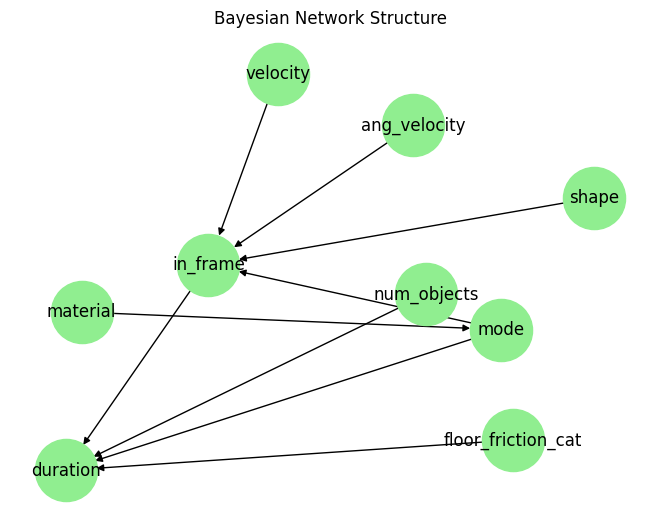

In [10]:
plot_network_structure(model)

In [11]:
test_scenario = {
    'shape': ["cube", "ball"],
    'material': ['rubber', "metal"],
    'mode': ['collision', 'sliding'],
    'velocity': [[1.2, -0.3, 0.1], [0.8, -0.2, 0.05]],
    'angular_velocity': [[0.4, 0.1, -0.2], [0.1, 0.05, -0.1]],
    'floor_friction': "0.1 0.2 0.15",
    'obj_friction': ["0.8 0.7 0.9", "0.5 0.6 0.55"]
}

# First verify model structure
print("Model nodes:", model.nodes())


result = predict_duration_multi_object(model, test_scenario)

if 'prediction' in result:
    print("Prediction successful:")
    print(result['prediction'])
    print("\nUsed evidence:")
    print(result['used_evidence'])
else:
    print(result)
    print("Prediction failed:")
    # print(result['error'])
    # print("\nDebug info:")
    # print(result['input_data'])
    # print(result['processed_evidence'])

Model nodes: ['num_objects', 'duration', 'floor_friction_cat', 'shape', 'in_frame', 'material', 'mode', 'velocity', 'ang_velocity']
Prediction successful:
+----------------+-----------------+
| duration       |   phi(duration) |
+================+=================+
| duration(long) |          1.0000 |
+----------------+-----------------+

Used evidence:
{'num_objects': 2, 'floor_friction_cat': 'medium', 'shape': 'cube', 'material': 'rubber', 'mode': 'collision', 'velocity': 'low', 'ang_velocity': 'low'}


Marginal probability for 'duration':
+----------------+-----------------+
| duration       |   phi(duration) |
+================+=================+
| duration(long) |          1.0000 |
+----------------+-----------------+


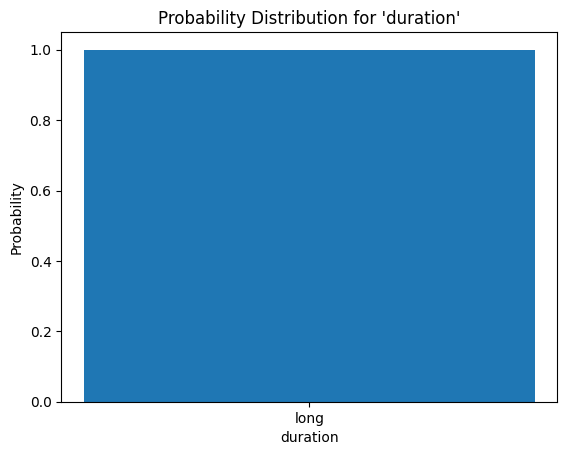

In [12]:

infer = VariableElimination(model)


evidence = {
    'mode': 'collision',
    'floor_friction_cat': 'medium',
    'velocity': 'low',
    'shape': 'ball',
    'material': 'rubber',
    'num_objects': 2,
    'ang_velocity': 'low'
}


duration_prob = infer.query(variables=['duration'], evidence=evidence)
# duration_prob = result[prediction]
print("Marginal probability for 'duration':")
print(duration_prob)


def plot_distribution(query_result, node_name):
    values = query_result.values
    states = query_result.state_names[node_name]
    
    # Create a bar plot for the probability distribution
    plt.bar(states, values)
    plt.xlabel(node_name)
    plt.ylabel("Probability")
    plt.title(f"Probability Distribution for '{node_name}'")
    plt.show()


plot_distribution(duration_prob, 'duration')


### VAE

In [2]:
class DurationPredictorVAE(nn.Module):
    def __init__(self, input_dim, latent_dim=16):
        super().__init__()

        # encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )
            
        self.fc1 = nn.Linear(64, 64)
        self.fc_mu = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)

        # decoder
        self.fc_decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 2) #  mean, log-variance
        )

    def encode(self, x):
        h = self.encoder(x)
        h = self.fc1(h)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        params = self.fc_decoder(z)
        mu_pred = params[:, 0]
        logvar_pred = params[:, 1]
        return mu_pred, logvar_pred

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


def loss_function(predictions, targets, mu, logvar):
    pred_mu, pred_logvar = predictions
    #  Gaussian negative log-likelihood
    nll_loss = 0.5 * torch.sum(pred_logvar + ((targets.squeeze() - pred_mu) ** 2) / torch.exp(pred_logvar))
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return nll_loss + kl_loss
    

In [3]:
def load_data_files(directory):
    data = []
    files = glob.glob(directory + '/**/*.json', recursive=True)
    for filename in files:
        if "obj.json" in filename:
            with open(filename, 'r') as file:
                data.append(json.load(file))
    return data


def load_data(annotation_data):
    inputs, targets = [], []
    
    world = annotation_data.get("world")
    floor_friction = float(world['floor']['friction'].split(" ")[0])
    camera_distance = world['camera']['distance']
    camera_lookat = world['camera']['lookat']

    for frame in annotation_data['frames']:
        for obj_id, obj in frame['objects'].items():
            init_position = obj['position']
            # init_position = obj['prev_data']['position']
            velocity = obj['velocity']
            friction_values = obj.get('friction', "0.3").split(" ")
            friction = float(friction_values[0])

            bbox = obj.get("bbox", [[0, 0], [0, 0]])
            in_frame = 1.0 if (bbox[0] != bbox[1]) else 0.0

          
            
            init_position_np = np.array(init_position)
            velocity_np = np.array(velocity)
            camera_lookat_np = np.array(camera_lookat)
            distance = np.linalg.norm(init_position_np - camera_lookat_np) + 1e-5
      
            visible_duration = (np.linalg.norm(velocity_np) / distance) * in_frame
            # print(visible_duration)

            input_vector = (
                init_position + 
                velocity + 
                [friction, floor_friction, camera_distance] + 
                camera_lookat + 
                [in_frame] 
                # [visible_duration]
            )

            # print(visible_duration)
            inputs.append(input_vector)
            targets.append([visible_duration])

    inputs_tensor = torch.tensor(inputs, dtype=torch.float32)
    
    target = np.mean(targets) if targets else 0.0
    target_tensor = torch.tensor([target], dtype=torch.float32)
    return inputs_tensor, target_tensor


def load_dataset(directory):
    annotations = load_data_files(directory)
    inputs_list, targets_list = [], []
    for ann in annotations:
        x, y = load_data(ann)
        inputs_list.append(x)
        targets_list.append(y)
    return inputs_list, targets_list



def collate_video(batch):
    batch_inputs = []
    batch_targets = []

    for inputs_tensor, target_tensor in batch:
        # agrigate over the objects in the video - avg pooling
        video_feature = inputs_tensor.mean(dim=0)
        batch_inputs.append(video_feature)
        batch_targets.append(target_tensor)
        
    batch_inputs = torch.stack(batch_inputs)
    batch_targets = torch.stack(batch_targets)
    return batch_inputs, batch_targets

In [4]:
directory = 'generated'
inputs_list, targets_list = load_dataset(directory)

indices = list(range(len(inputs_list)))
train_indices, test_indices = train_test_split(indices, test_size=0.2, random_state=42)


train_dataset = [(inputs_list[i], targets_list[i]) for i in train_indices]
test_dataset = [(inputs_list[i], targets_list[i]) for i in test_indices]


batch_size = 4
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_video)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_video)

input_dim = inputs_list[0].shape[1]


In [5]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = DurationPredictorVAE(input_dim=input_dim, latent_dim=16).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)



cpu


In [7]:
from sklearn.metrics import mean_absolute_error
num_epochs = 200
train_loss_history = []
test_loss_history = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    
    for batch_inputs, batch_targets in train_loader:
        batch_inputs = batch_inputs.to(device)
        batch_targets = batch_targets.to(device)
        optimizer.zero_grad()
        predictions, mu, logvar = model(batch_inputs)
        loss = loss_function(predictions, batch_targets, mu, logvar)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * batch_inputs.size(0)
    train_loss /= len(train_dataset)
    
    
    model.eval()
    test_loss = 0.0
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for batch_inputs, batch_targets in test_loader:
            batch_inputs = batch_inputs.to(device)
            batch_targets = batch_targets.to(device)
           
            predictions, mu, logvar = model(batch_inputs)
            loss = loss_function(predictions, batch_targets, mu, logvar)
            test_loss += loss.item() * batch_inputs.size(0)

            pred_mu, _ = predictions
            all_preds.extend(pred_mu.cpu().numpy().flatten().tolist())
            all_targets.extend(batch_targets.cpu().numpy().flatten().tolist())
    test_loss /= len(test_dataset)
    mae = mean_absolute_error(all_targets, all_preds)
    
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}, Test MAE: {mae:.4f}")
    train_loss_history.append(train_loss)
    test_loss_history.append(test_loss)


Epoch 1/200, Train Loss: -2.4652, Test Loss: -2.6604, Test MAE: 0.2154
Epoch 2/200, Train Loss: -2.5652, Test Loss: -2.9496, Test MAE: 0.2168
Epoch 3/200, Train Loss: -2.7106, Test Loss: -2.9291, Test MAE: 0.2089
Epoch 4/200, Train Loss: -2.4753, Test Loss: -3.1696, Test MAE: 0.1954
Epoch 5/200, Train Loss: -2.6820, Test Loss: -2.7424, Test MAE: 0.2224
Epoch 6/200, Train Loss: -2.6750, Test Loss: -2.8655, Test MAE: 0.2049
Epoch 7/200, Train Loss: -2.8246, Test Loss: -2.7319, Test MAE: 0.2095
Epoch 8/200, Train Loss: -2.6660, Test Loss: -2.9172, Test MAE: 0.2043
Epoch 9/200, Train Loss: -2.9526, Test Loss: -2.8138, Test MAE: 0.2068
Epoch 10/200, Train Loss: -2.5152, Test Loss: -3.2585, Test MAE: 0.1952
Epoch 11/200, Train Loss: -2.8427, Test Loss: -2.6884, Test MAE: 0.1966
Epoch 12/200, Train Loss: -2.8663, Test Loss: -3.1232, Test MAE: 0.1887
Epoch 13/200, Train Loss: -2.8129, Test Loss: -2.8572, Test MAE: 0.1999
Epoch 14/200, Train Loss: -2.6227, Test Loss: -2.9032, Test MAE: 0.1993
E

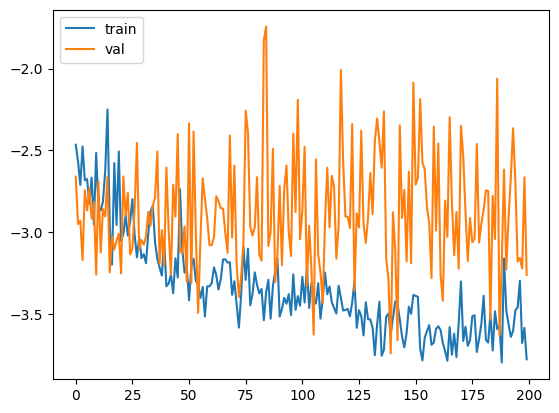

In [8]:
plt.plot(train_loss_history)
plt.plot(test_loss_history)
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [187]:
def predict_duration(model, video_inputs_tensor):
    model.eval()
    with torch.no_grad():
        video_feature = video_inputs_tensor.mean(dim=0).unsqueeze(0).to(device)
        predictions, mu, var = model(video_feature)
        
        print("mu, var", mu, var)
        print("predictions", predictions)
        pred_mu, _ = predictions
    return pred_mu.item()


sample_video = test_dataset[2][0]
predicted_duration = predict_duration(model, sample_video)

predicted_duration

mu, var tensor([[-0.0159, -0.0141,  0.1493, -0.0310,  0.0154,  0.0265,  0.1647, -0.0095,
          0.0234,  0.0313, -0.0183, -0.0091, -0.0061, -0.0076,  0.0086, -0.0166]]) tensor([[-0.0097,  0.0042, -0.0702,  0.0141, -0.0097, -0.0072, -0.0649,  0.0014,
          0.0045,  0.0022,  0.0053,  0.0029,  0.0029,  0.0030, -0.0079,  0.0077]])
predictions (tensor([0.2467]), tensor([-3.3209]))


0.2467144876718521

In [188]:
test_dataset[2][1]

tensor([0.0879])

In [189]:
def compute_in_frame(camera, object_position, fov_deg=60):
    lookat = camera.get("lookat", [0, 0, 0])
    distance = camera.get("distance", 3.0)
    azimuth_deg = camera.get("azimuth", 0)
    elevation_deg = camera.get("elevation", 0)
    
    azimuth = math.radians(azimuth_deg)
    elevation = math.radians(elevation_deg)

    cam_x = lookat[0] + distance * math.cos(elevation) * math.sin(azimuth)
    cam_y = lookat[1] + distance * math.cos(elevation) * math.cos(azimuth)
    cam_z = lookat[2] + distance * math.sin(elevation)
    camera_pos = np.array([cam_x, cam_y, cam_z])

    view_direction = np.array(lookat) - camera_pos
    view_direction = view_direction / np.linalg.norm(view_direction)
    
    obj_pos = np.array(object_position)

    obj_direction = obj_pos - camera_pos
    norm = np.linalg.norm(obj_direction)
    if norm == 0:
        return 0.0 
    obj_direction = obj_direction / norm

    dot_product = np.dot(view_direction, obj_direction)
    dot_product = np.clip(dot_product, -1.0, 1.0)
    angle = math.acos(dot_product)

    half_fov = math.radians(fov_deg / 2)
    return 1.0 if angle < half_fov else 0.0


def load_initial_data(initial_data):
    inputs = []
    world = initial_data.get("world", {})
    floor_friction = float(world.get("floor", {}).get("friction", "0.3").split(" ")[0])
    camera_distance = world.get("camera", {}).get("distance", 0)
    camera_lookat = world.get("camera", {}).get("lookat", [])
    
    for obj in initial_data.get("objects", []):
        x = obj.get("init_possition_x", 0)
        y = obj.get("init_possition_y", 0)
        z = obj.get("base_z", 0)
        init_position = [x, y, z]

        velocity = obj.get("velocity", [0, 0, 0])
        friction = float(obj.get("friction", "0.3").split(" ")[0])
        
        in_frame = compute_in_frame(world.get("camera", {}), init_position)
        print(in_frame)
        # [init_position, velocity, friction, floor_friction, camera_distance, camera_lookat, in_frame]
        feature = init_position + velocity + [friction, floor_friction, camera_distance] + camera_lookat + [in_frame]
        inputs.append(feature)
    
    inputs_tensor = torch.tensor(inputs, dtype=torch.float32)
    return inputs_tensor

def predict_video_duration_from_initial_data(model, initial_data, device):

    model.eval()

    inputs_tensor = load_initial_data(initial_data)

    video_feature = inputs_tensor.mean(dim=0).unsqueeze(0).to(device)
    
    with torch.no_grad():
        predictions, mu, logvar = model(video_feature)
        pred_mu, _ = predictions
    return pred_mu.item()


In [190]:
initial_data = {
  "world": {
    "floor": {
      "friction": "0.8404828595293601 0.2228827813585779 0.15824754444399414",
      "texture": "gradient",
      "rgba": "0.83 0.83 0.83 1",
      "specular": "0.295710",
      "shininess": "0.295710"
    },
    "camera": {
      "camera_name": "camera",
      "lookat": [
        -0.17433918940451876,
        -0.37430520105728315,
        0.19604048937942722
      ],
      "distance": 2.9545659466934837,
      "azimuth": 218.41826798522425,
      "elevation": -14.10537861490267,
      "prev_lookat": [
        -0.17433918940451876,
        -0.37430520105728315,
        0.19604048937942722
      ],
      "prev_distance": 2.9545659466934837,
      "alpha": 0.1
    },
    "lights": [
      {
        "pos": [
          -0.8416212142572452,
          -0.7108580567394487,
          0.3627502232450899
        ],
        "diffuse": "0.8130771927948659 0.8161898881930906 0.9445400937401079",
        "specular": "0.5373498219910978 0.9026299652401331 0.7639751215092606",
        "cutoff": 124.01120203625337,
        "directional": False
      },
      {
        "pos": [
          -0.3826075378781686,
          0.6218826594901052,
          0.3638861357822021
        ],
        "diffuse": "0.953315188259986 0.8564591266115733 0.8476306488928885",
        "specular": "0.7082137325946859 0.7622521195177517 0.9430052973675681",
        "cutoff": 133.97727079123038,
        "directional": False
      }
    ]
  },
  "objects": [
    {
      "shape": "cube",
      "material": "glass",
      "material_shininess": 50,
      "dimensions": {
        "side": 0.054371047067494016
      },
      "mass": 0.3936583965865026,
      "density": 2449.155891221033,
      "elasticity": 0.516,
      "friction": "0.21 0.15 0.19",
      "visual": {
        "rgba": "0.500 0.300 0.100 0.500",
        "specular": 0.6
      },
      "velocity": [
        2.269907459819992,
        -0.21933942663189845,
        -0.05534667607380792
      ],
      "angular_velocity": [
        0.5496235321247394,
        -0.31398564452043853,
        -0.0024874882288425937
      ],
      "mode": "sliding",
      "init_possition_x": -1.583485656362974,
      "init_possition_y": -0.02787696492756846,
      "collision_radius": 1.5993639769373766,
      "volume": 0.00016073227433074632,
      "base_z": 0.027185523533747008,
      "geom_type": "box",
      "size_str": "0.0272 0.0272 0.0272",
      "geom_id": 1,
      "id": "geom_obj0"
    },
    {
      "shape": "cylinder",
      "material": "rubber",
      "material_shininess": 0,
      "dimensions": {
        "radius": 0.09671830155883088,
        "height": 0.18023482663669668
      },
      "mass": 6.02814995260241,
      "density": 1138.0940121094927,
      "elasticity": 1,
      "friction": "1.13 1.12 0.95",
      "visual": {
        "rgba": "0.700 0.100 0.100 1.000",
        "specular": 0.0
      },
      "velocity": [
        -1.2934981605182372,
        2.9084056124586968,
        0.12987059231821912
      ],
      "angular_velocity": [
        0.8927232643710132,
        0.3228393777821972,
        -0.06876452130941413
      ],
      "mode": "collision",
      "init_possition_x": 0.4189706927513894,
      "init_possition_y": -0.9420475045481664,
      "collision_radius": 1.0310140358937927,
      "volume": 0.005296706500923457,
      "base_z": 0.09011741331834834,
      "geom_type": "cylinder",
      "size_str": "0.0967 0.0901",
      "geom_id": 2,
      "id": "geom_obj1"
    },
    {
      "shape": "cube",
      "material": "metal",
      "material_shininess": 100,
      "dimensions": {
        "side": 0.07164704660115775
      },
      "mass": 3.297861246269041,
      "density": 8966.800363594768,
      "elasticity": 0.858,
      "friction": "0.27 0.28 0.27",
      "visual": {
        "rgba": "0.300 0.800 1.000 1.000",
        "specular": 1.0
      },
      "velocity": [
        -3.572698068578978,
        0.3846908234308662,
        -0.14371023449811188
      ],
      "angular_velocity": [
        -0.23283600570777918,
        -0.893346438925257,
        -0.2875061767910523
      ],
      "mode": "collision",
      "init_possition_x": 1.6012282043079853,
      "init_possition_y": -0.1724124973877146,
      "collision_radius": 1.6104837259428746,
      "volume": 0.0003677857332096258,
      "base_z": 0.03582352330057888,
      "geom_type": "box",
      "size_str": "0.0358 0.0358 0.0358",
      "geom_id": 3,
      "id": "geom_obj2"
    },
    {
      "shape": "ball",
      "material": "glass",
      "material_shininess": 50,
      "dimensions": {
        "radius": 0.07862976253151271
      },
      "mass": 4.99629149866201,
      "density": 2453.5689499964046,
      "elasticity": 0.752,
      "friction": "0.20 0.21 0.21",
      "visual": {
        "rgba": "1.000 0.300 0.300 0.500",
        "specular": 0.6
      },
      "velocity": [
        -2.401505389316501,
        0.024581868760180647,
        -0.08741266892569424
      ],
      "angular_velocity": [
        -0.5691376753097099,
        -0.8810684714761798,
        0.8540298782502831
      ],
      "mode": "sliding",
      "init_possition_x": -0.5597629533906916,
      "init_possition_y": -0.4320496343241496,
      "collision_radius": 1.703650670626423,
      "volume": 0.002036336292350509,
      "base_z": 0.07862976253151271,
      "geom_type": "sphere",
      "size_str": "0.0786",
      "geom_id": 4,
      "id": "geom_obj3"
    },
    {
      "shape": "ball",
      "material": "plastic",
      "material_shininess": 5,
      "dimensions": {
        "radius": 0.09453275580499834
      },
      "mass": 4.16308031733403,
      "density": 1176.465577874913,
      "elasticity": 0.743,
      "friction": "0.38 0.30 0.53",
      "visual": {
        "rgba": "0.700 0.100 0.100 1.000",
        "specular": 0.3
      },
      "velocity": [
        0.0,
        0.0,
        0.0
      ],
      "angular_velocity": [
        -0.40977847243813414,
        -0.130310701238193,
        -0.3861580928888253
      ],
      "mode": "stationary",
      "init_possition_x": -1.7846457711556254,
      "init_possition_y": 0.11195306221301402,
      "collision_radius": 1.842099329852735,
      "volume": 0.0035386333400879723,
      "base_z": 0.09453275580499834,
      "geom_type": "sphere",
      "size_str": "0.0945",
      "geom_id": 5,
      "id": "geom_obj4"
    }
  ]
}


predicted_duration = predict_video_duration_from_initial_data(model, initial_data, device)
print( predicted_duration)


1.0
1.0
1.0
1.0
0.0


RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x13 and 14x128)

In [166]:
(1/predicted_duration)

2383.980139823304

### New approach

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import math
import json
import glob
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

In [23]:
import numpy as np
import torch
import json
import glob
from torch.utils.data import Dataset

def load_data_files(directory):
    data = []
    files = glob.glob(directory + '/**/*.json', recursive=True)
    for filename in files:
        if "obj.json" in filename:
            try:
                with open(filename, 'r') as file:
                    data.append(json.load(file))
            except (json.JSONDecodeError, KeyError) as e:
                print(f"Error loading {filename}: {str(e)}")
                continue
    return data

def process_frame_data(frame, world):
    frame_objects = []
    camera = world.get('camera', {})
    floor_friction = float(world.get('floor', {}).get('friction', "0.3").split(" ")[0])
    
    for obj_id, obj in frame.get('objects', {}).items():
        position = obj.get('position', [0, 0, 0])
        velocity = obj.get('velocity', [0, 0, 0])
        friction = float(obj.get('friction', "0.3").split(" ")[0])
        
        # Calculate if object is in frame (using both bbox and camera FOV)
        bbox = obj.get("bbox", [[0, 0], [0, 0]])
        bbox_in_frame = 1.0 if (bbox[0] != bbox[1]) else 0.0
        camera_in_frame = compute_in_frame(camera, position)
        in_frame = max(bbox_in_frame, camera_in_frame)
        
        # Calculate distance to camera lookat point
        distance = np.linalg.norm(np.array(position) - np.array(camera.get('lookat', [0,0,0]))) + 1e-5
        
        # Calculate visible duration heuristic
        speed = np.linalg.norm(velocity)
        visible_duration = (speed / distance) * in_frame if distance > 0 else 0.0
        
        # Create feature vector (13 dimensions)
        features = position + velocity + [
            friction,
            floor_friction,
            camera.get('distance', 0)
        ] + camera.get('lookat', [0,0,0]) + [in_frame]
        
        frame_objects.append({
            'features': features,
            'visible_duration': visible_duration
        })
    
    return frame_objects

class VideoDurationDataset(Dataset):
    def __init__(self, annotations, mode='vae', max_frames=64):
        self.annotations = annotations
        self.mode = mode
        self.max_frames = max_frames
        
    def __len__(self):
        return len(self.annotations)
    
    def __getitem__(self, idx):
        ann = self.annotations[idx]
        world = ann.get('world', {})
        frames = ann.get('frames', [])
        
        if self.mode == 'vae':
            frame_features = []
            frame_durations = []
            
            for frame in frames[:self.max_frames]:
                frame_objects = process_frame_data(frame, world)
                if frame_objects:
                    features = np.mean([obj['features'] for obj in frame_objects], axis=0)
                    durations = np.mean([obj['visible_duration'] for obj in frame_objects])
                    frame_features.append(features)
                    frame_durations.append(durations)
            
            # Pad sequence if needed
            if len(frame_features) < self.max_frames:
                padding = [np.zeros(13) for _ in range(self.max_frames - len(frame_features))]
                frame_features.extend(padding)
                frame_durations.extend([0] * (self.max_frames - len(frame_durations)))
            
            # Target is the normalized duration (0-1)
            duration = len(frames) / 100.0  # Assuming max 100 frames
            return torch.FloatTensor(frame_features), torch.FloatTensor([duration])
        
        else:  # predictor mode
            initial_objects = []
            for obj in ann.get('objects', []):
                pos_x = obj.get('init_possition_x', obj.get('init_position_x', 0))
                pos_y = obj.get('init_possition_y', obj.get('init_position_y', 0))
                pos_z = obj.get('base_z', 0)
                position = [pos_x, pos_y, pos_z]
                
                velocity = obj.get('velocity', [0, 0, 0])
                friction = float(obj.get('friction', "0.3").split(" ")[0])
                
                # Calculate initial frame visibility
                in_frame = compute_in_frame(world.get('camera', {}), position)
                
                features = position + velocity + [
                    friction,
                    float(world.get('floor', {}).get('friction', "0.3").split(" ")[0]),
                    world.get('camera', {}).get('distance', 0)
                ] + world.get('camera', {}).get('lookat', [0,0,0]) + [in_frame]
                
                initial_objects.append(features)
            
            if not initial_objects:
                initial_objects = [np.zeros(13)]
            
            # Average initial object features
            initial_feature = np.mean(initial_objects, axis=0)
            
            # Target is the normalized duration (0-1)
            duration = len(frames) / 100.0  # Assuming max 100 frames
            return torch.FloatTensor(initial_feature), torch.FloatTensor([duration])

def create_dataloaders(data_dir, batch_size=32, test_size=0.2):
    """Create train and test dataloaders for both VAE and predictor"""
    annotations = load_data_files(data_dir)
    train_ann, test_ann = train_test_split(annotations, test_size=test_size)
    
    # Create datasets
    vae_train = VideoDurationDataset(train_ann, mode='vae')
    vae_test = VideoDurationDataset(test_ann, mode='vae')
    pred_train = VideoDurationDataset(train_ann, mode='predictor')
    pred_test = VideoDurationDataset(test_ann, mode='predictor')
    
    # Create dataloaders
    vae_train_loader = DataLoader(vae_train, batch_size=batch_size, shuffle=True)
    vae_test_loader = DataLoader(vae_test, batch_size=batch_size)
    pred_train_loader = DataLoader(pred_train, batch_size=batch_size, shuffle=True)
    pred_test_loader = DataLoader(pred_test, batch_size=batch_size)
    
    return {
        'vae': {'train': vae_train_loader, 'test': vae_test_loader},
        'predictor': {'train': pred_train_loader, 'test': pred_test_loader}
    }


In [10]:
def compute_in_frame(camera, object_position, fov_deg=60, aspect_ratio=16/9):
    lookat = np.array(camera.get("lookat", [0, 0, 0]))
    distance = camera.get("distance", 3.0)
    azimuth_deg = camera.get("azimuth", 0)
    elevation_deg = camera.get("elevation", 0)
    
    azimuth = math.radians(azimuth_deg)
    elevation = math.radians(elevation_deg)
    
    cam_x = lookat[0] + distance * math.cos(elevation) * math.sin(azimuth)
    cam_y = lookat[1] + distance * math.cos(elevation) * math.cos(azimuth)
    cam_z = lookat[2] + distance * math.sin(elevation)
    camera_pos = np.array([cam_x, cam_y, cam_z])
    
    view_direction = lookat - camera_pos
    view_direction = view_direction / np.linalg.norm(view_direction)
    
    obj_pos = np.array(object_position)
    obj_direction = obj_pos - camera_pos
    obj_distance = np.linalg.norm(obj_direction)
    
    if obj_distance < 1e-5:
        return 0.0
    
    obj_direction = obj_direction / obj_distance

    ot_product = np.dot(view_direction, obj_direction)
    dot_product = np.clip(dot_product, -1.0, 1.0)
    angle = math.acos(dot_product)
    
    half_h_fov = math.radians(fov_deg / 2)
    half_v_fov = math.atan(math.tan(half_h_fov) / aspect_ratio)
    
    horizontal_angle = math.atan2(obj_direction[0], obj_direction[1]) - azimuth
    vertical_angle = math.asin(obj_direction[2] / obj_distance) - elevation
    
    in_frame = (abs(horizontal_angle) < half_h_fov and 
                abs(vertical_angle) < half_v_fov)
    
    return 1.0 if in_frame else 0.0


    

In [11]:
class VideoVAE(nn.Module):
    def __init__(self, input_dim=13, latent_dim=16, temporal_dim=32):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )
        
        self.temporal_rnn = nn.GRU(64, temporal_dim, batch_first=True)
        self.fc_mu = nn.Linear(temporal_dim, latent_dim)
        self.fc_logvar = nn.Linear(temporal_dim, latent_dim)
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )
    def encode(self, x):
        batch_size, seq_len, _ = x.shape
        x = x.view(-1, x.size(-1))
        h = self.encoder(x)
        h = h.view(batch_size, seq_len, -1)
        
        _, h_temporal = self.temporal_rnn(h)
        h_temporal = h_temporal.squeeze(0)
        
        return self.fc_mu(h_temporal), self.fc_logvar(h_temporal)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar



class DurationPredictor(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Softplus()
        )
    
    def forward(self, z):
        return self.model(z)

In [12]:
class VAEDataset(Dataset):
    def __init__(self, annotations):
        self.annotations = annotations
        self.max_frames = 64  # Maximum frames to consider per video
        
    def __len__(self):
        return len(self.annotations)
    
    def __getitem__(self, idx):
        ann = self.annotations[idx]
        world = ann.get("world", {})
        floor_friction = float(world.get("floor", {}).get("friction", "0.3").split(" ")[0])
        camera = world.get("camera", {})
        
        frame_features = []
        for frame in ann.get("frames", [])[:self.max_frames]:
            frame_objs = []
            for obj_id, obj in frame.get("objects", {}).items():
                position = obj.get("position", [0, 0, 0])
                velocity = obj.get("velocity", [0, 0, 0])
                friction = float(obj.get("friction", "0.3").split(" ")[0])
                in_frame = compute_in_frame(camera, position)
                
                features = position + velocity + [
                    friction, 
                    floor_friction, 
                    camera.get("distance", 0)
                ] + camera.get("lookat", [0, 0, 0]) + [in_frame]
                
                frame_objs.append(features)
            
            if frame_objs:
                frame_feature = np.mean(frame_objs, axis=0)
                frame_features.append(frame_feature)
        
        if not frame_features:
            frame_features = [np.zeros(13)]
        
        # padding
        if len(frame_features) < self.max_frames:
            padding = [np.zeros(13) for _ in range(self.max_frames - len(frame_features))]
            frame_features.extend(padding)
        
        # Target is the normalized duration (0-1)
        duration = len(ann.get("frames", [])) / 100.0  # assuming max 100 frames
        return torch.FloatTensor(frame_features[:self.max_frames]), torch.FloatTensor([duration])

In [13]:
def train_vae(model, dataloader, optimizer, device, epochs=50):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch_idx, (inputs, _) in enumerate(dataloader):
            inputs = inputs.to(device)
            
            optimizer.zero_grad()
            recon_batch, mu, logvar = model(inputs)
            
            recon_loss = F.mse_loss(recon_batch, inputs, reduction='sum')
            kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
            
            loss = recon_loss + kl_loss
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        print(f'VAE Epoch {epoch+1}, Loss: {total_loss/len(dataloader.dataset):.4f}')

def train_duration_predictor(vae, predictor, dataloader, optimizer, device, epochs=30):
    vae.eval()
    predictor.train()
    
    for epoch in range(epochs):
        total_loss = 0
        for batch_idx, (inputs, targets) in enumerate(dataloader):
            inputs, targets = inputs.to(device), targets.to(device)
            
            optimizer.zero_grad()
            
            with torch.no_grad():
                mu, _ = vae.encode(inputs.unsqueeze(1))  # Add sequence dim
                z = vae.reparameterize(mu, torch.zeros_like(mu))
            
            pred_duration = predictor(z)
            loss = F.mse_loss(pred_duration.squeeze(), targets.squeeze())
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        print(f'Predictor Epoch {epoch+1}, Loss: {total_loss/len(dataloader.dataset):.4f}')


In [16]:
directory = 'generated'
data_loader = create_dataloaders(directory)



In [17]:
data_loader

{'vae': {'train': <torch.utils.data.dataloader.DataLoader at 0x15f05e850>,
  'test': <torch.utils.data.dataloader.DataLoader at 0x1461bac40>},
 'predictor': {'train': <torch.utils.data.dataloader.DataLoader at 0x14082ce90>,
  'test': <torch.utils.data.dataloader.DataLoader at 0x15c6ab0b0>}}

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae = VideoVAE().to(device)
predictor = DurationPredictor().to(device)

In [22]:
vae_optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)
print("Training VAE...")
train_vae(vae, data_loader['vae']['train'], vae_optimizer, device)

Training VAE...


UnboundLocalError: cannot access local variable 'dot_product' where it is not associated with a value

In [ ]:
def predict_duration(vae, predictor, initial_data, device):
    vae.eval()
    predictor.eval()
    
    world = initial_data.get("world", {})
    floor_friction = float(world.get("floor", {}).get("friction", "0.3").split(" ")[0])
    camera = world.get("camera", {})
    
    initial_objs = []
    for obj in initial_data.get("objects", []):
        pos_x = obj.get("init_possition_x", obj.get("init_position_x", 0))
        pos_y = obj.get("init_possition_y", obj.get("init_position_y", 0))
        pos_z = obj.get("base_z", 0)
        position = [pos_x, pos_y, pos_z]
        
        velocity = obj.get("velocity", [0, 0, 0])
        friction = float(obj.get("friction", "0.3").split(" ")[0])
        in_frame = compute_in_frame(camera, position)
        
        features = position + velocity + [
            friction, 
            floor_friction, 
            camera.get("distance", 0)
        ] + camera.get("lookat", [0, 0, 0]) + [in_frame]
        
        initial_objs.append(features)
    
    if not initial_objs:
        return 0.0
    
    initial_feature = np.mean(initial_objs, axis=0)
    inputs = torch.FloatTensor(initial_feature).unsqueeze(0).unsqueeze(0).to(device)
    
    with torch.no_grad():
        mu, _ = vae.encode(inputs)
        z = vae.reparameterize(mu, torch.zeros_like(mu))
        duration = predictor(z)
    
    return max(0, duration.item() * 100)  # Convert back to frame count
